  Netflix EdTech — Monte Carlo Simulation (N = 10,000)
  ALY 6130 | Group 4 | Module 4 Assignment

─────────────────────────────────────────────────────────────────
  R6 | Initial Capital Investment Exceeding Projections
  Distribution  : PERT/Beta
  P(Occurrence) : 87%
  Mean Loss     : $116.0M
  Std Dev       : $53.9M
  P(50)         : $124.8M
  P(80)         : $158.0M
  P(90)         : $174.7M
  VaR 95%       : $187.5M
  Quant. Score  : 11.6

─────────────────────────────────────────────────────────────────
  R16 | Coursera-Udemy Merger Competitive Displacement
  Distribution  : Normal + Fat-Tail
  P(Occurrence) : 91%
  Mean Loss     : $162.1M
  Std Dev       : $76.0M
  P(50)         : $168.4M
  P(80)         : $216.9M
  P(90)         : $243.2M
  VaR 95%       : $267.5M
  Quant. Score  : 16.1

─────────────────────────────────────────────────────────────────
  R28 | Limited Educational AI Training Data for Models
  Distribution  : Log-Normal
  P(Occurrence) : 83%
  Mean Loss     : $

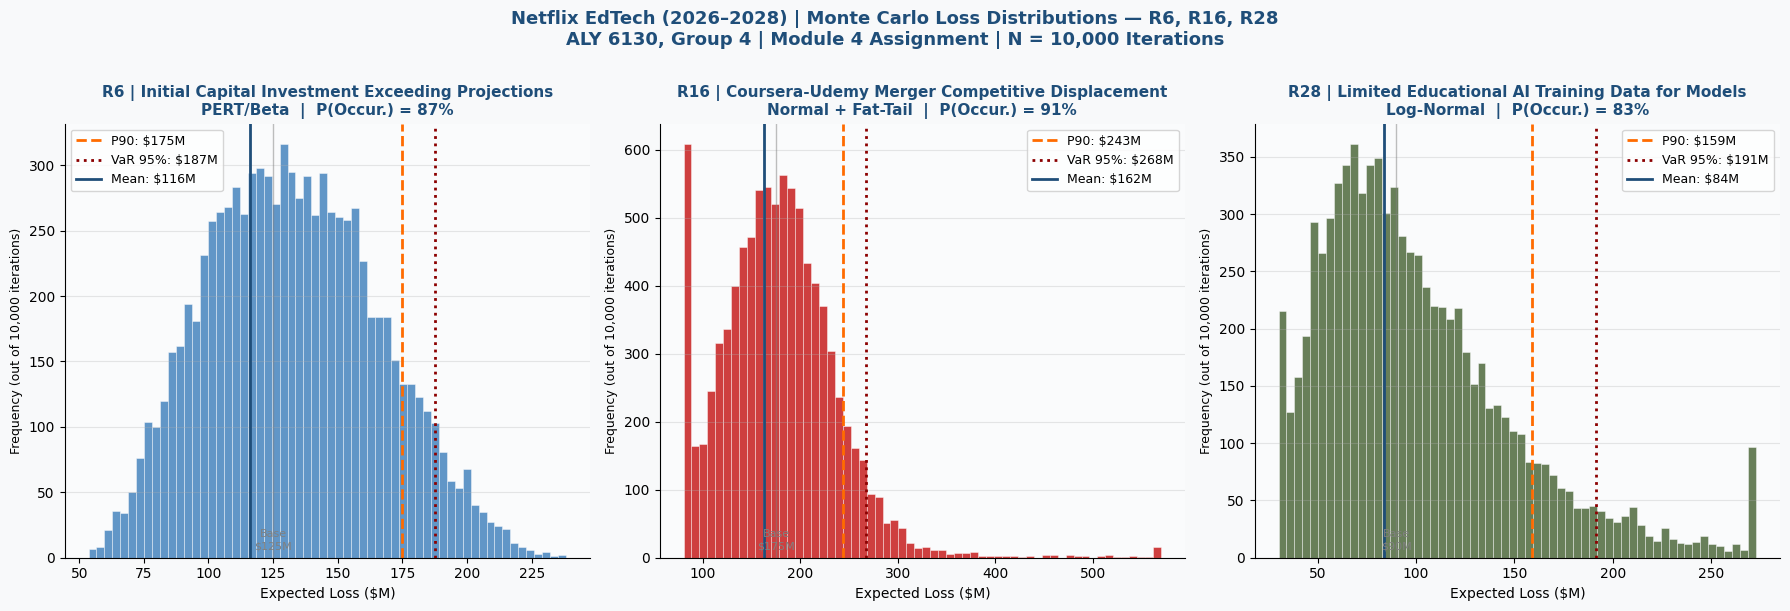

Figure 1 saved: Figure1_MonteCarlo_Distributions.png


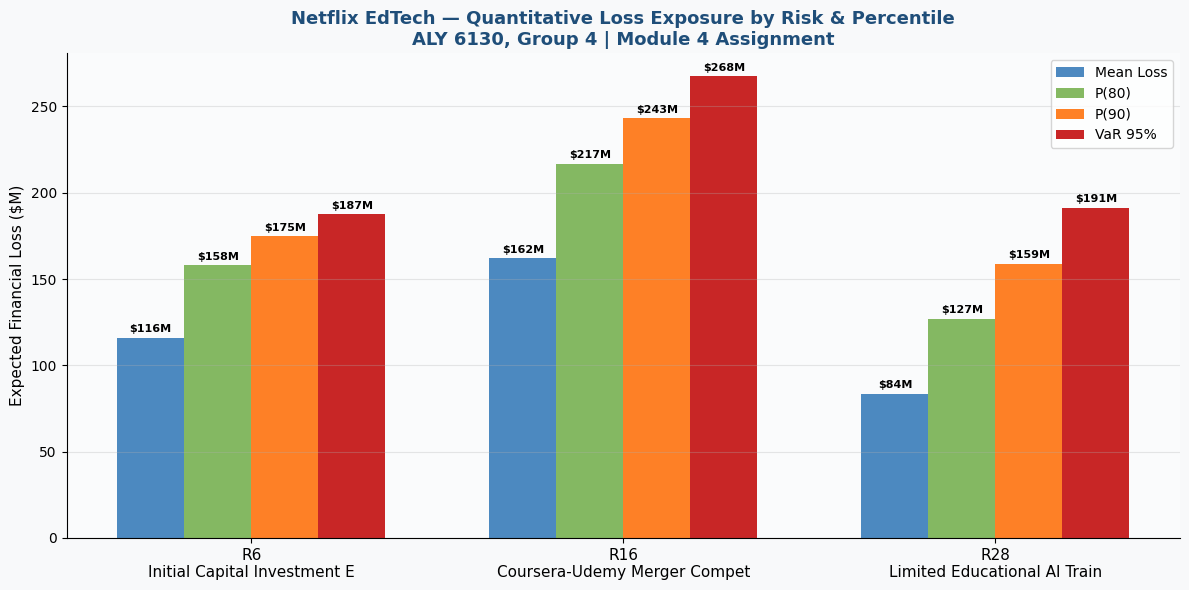

Figure 2 saved: Figure2_Percentile_Comparison.png


/tmp/ipykernel_4266/3221734718.py:395: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4266/3221734718.py:396: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('Figure3_Updated_Heatmap.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


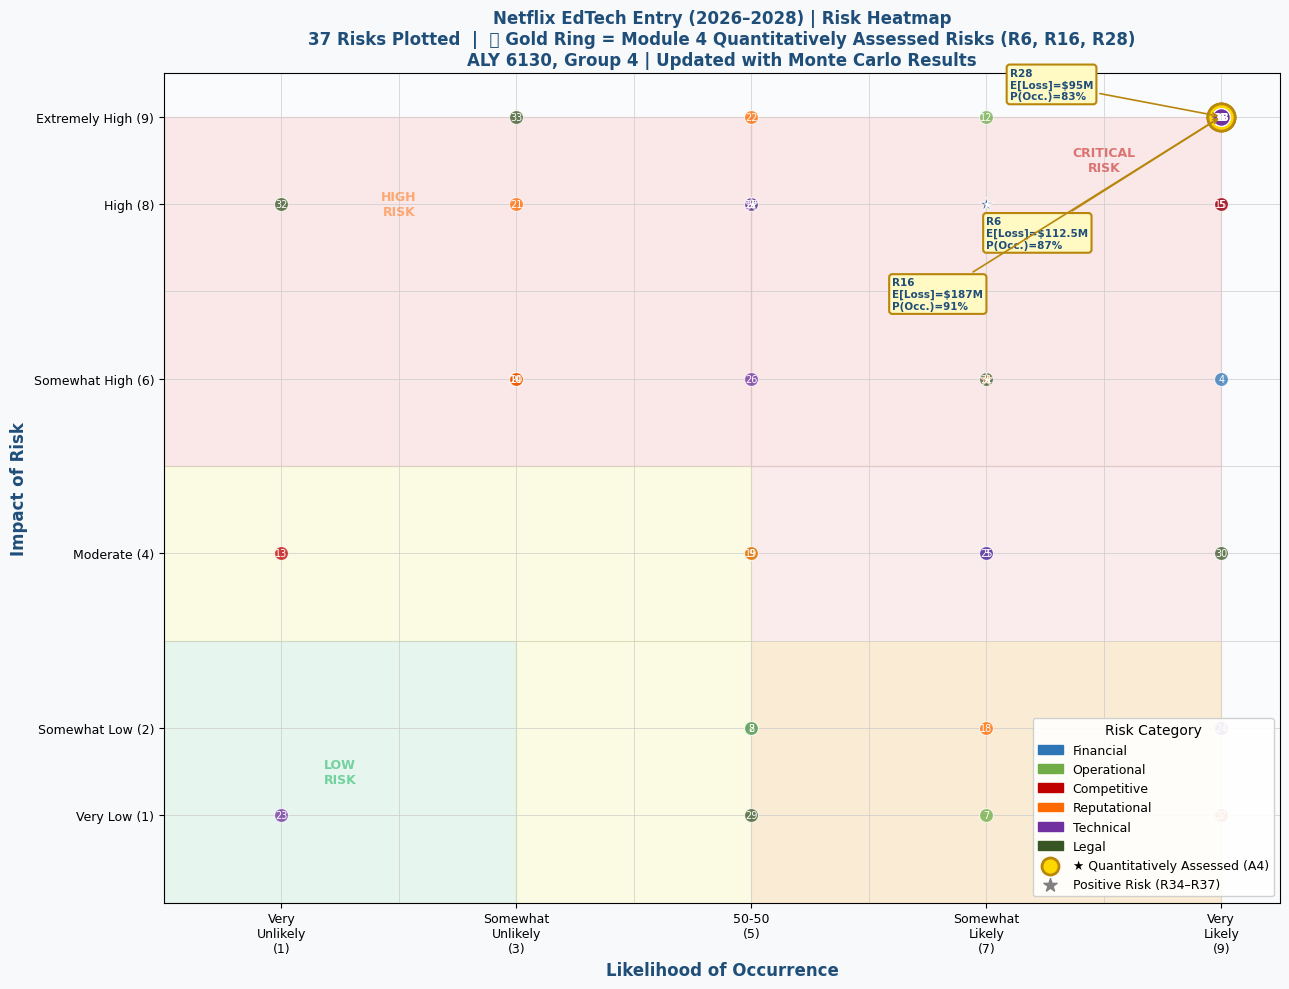

Figure 3 saved: Figure3_Updated_Heatmap.png

  MONTE CARLO SUMMARY TABLE
Risk                                             Name      Distribution P(Occurrence) Mean Loss ($M) Std Dev ($M) P(80) ($M) P(90) ($M) VaR 95% ($M)  Quant. Score
  R6 Initial Capital Investment Exceeding Projections         PERT/Beta           87%        $116.0M       $53.9M    $158.0M    $174.7M      $187.5M          11.6
 R16   Coursera-Udemy Merger Competitive Displacement Normal + Fat-Tail           91%        $162.1M       $76.0M    $216.9M    $243.2M      $267.5M          16.1
 R28  Limited Educational AI Training Data for Models        Log-Normal           83%         $83.6M       $58.8M    $127.1M    $158.9M      $191.3M           8.4

  Combined Mean Exposure : $361.7M
  Combined P(90) Exposure: $576.8M

All figures saved. Ready for submission.
Append Figure1, Figure2, Figure3 PNGs to your Word report.


In [4]:
# ALY 6130 — Group 4 | Module 4 Assignment
# Netflix EdTech Entry (2026–2028) | Quantitative Risk Assessment
# Indicators & Warning (I&W) + Monte Carlo Simulation
# =============================================================================
# HOW TO RUN: Upload this file to Google Colab and run all cells (Runtime > Run all)
# Required libraries: numpy, scipy, matplotlib, pandas — all pre-installed in Colab
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

np.random.seed(42)          # reproducibility
N = 10_000                  # Monte Carlo iterations

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — RISK DATA (from Assignment 3 Risk Register)
# ─────────────────────────────────────────────────────────────────────────────

risks = {
    'R6': {
        'name': 'Initial Capital Investment\nExceeding Projections',
        'category': 'Financial',
        'low': 50, 'base': 125, 'high': 250,       # $M
        'distribution': 'PERT/Beta',
        'qual_likelihood': 9, 'qual_impact': 9,
    },
    'R16': {
        'name': 'Coursera-Udemy Merger\nCompetitive Displacement',
        'category': 'Competitive',
        'low': 80, 'base': 175, 'high': 380,
        'distribution': 'Normal + Fat-Tail',
        'qual_likelihood': 9, 'qual_impact': 9,
    },
    'R28': {
        'name': 'Limited Educational AI\nTraining Data for Models',
        'category': 'Technical',
        'low': 30, 'base': 90, 'high': 210,
        'distribution': 'Log-Normal',
        'qual_likelihood': 9, 'qual_impact': 9,
    },
}


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — MONTE CARLO SIMULATION FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def pert_beta_samples(low, base, high, n):
    """
    PERT/Beta distribution — used for R6 (cost overrun).
    Skewed toward the base estimate; captures asymmetric cost risk.
    Lambda = 4 (standard PERT shape parameter).
    """
    lam = 4
    mean = (low + lam * base + high) / (lam + 2)
    a = ((mean - low) / (high - low)) * ((mean - low) * (high - mean) / ((high - low) ** 2) *
         (lam + 2) - 1 / (lam + 2)) * (lam + 2)
    b = a * (high - mean) / (mean - low)
    if a <= 0 or b <= 0:
        a, b = 2.0, 4.0
    samples = low + stats.beta.rvs(a, b, size=n) * (high - low)
    return samples


def normal_fat_tail_samples(low, base, high, n):
    """
    Normal distribution + fat-tail (t-distribution mixture) — used for R16.
    Captures competitive displacement where extreme outcomes are more likely
    than a pure normal would suggest (merger shock, market consolidation).
    """
    sigma = (high - low) / 6
    normal_part = np.random.normal(base, sigma, int(n * 0.8))
    fat_tail = stats.t.rvs(df=3, loc=base, scale=sigma * 1.5, size=int(n * 0.2))
    samples = np.concatenate([normal_part, fat_tail])
    samples = np.clip(samples, low, high * 1.5)   # allow slight upside tail
    return samples[:n]


def lognormal_samples(low, base, high, n):
    """
    Log-normal distribution — used for R28.
    Appropriate for AI data gap costs: bounded below (zero cost if solved early),
    but long right tail if the problem compounds over time.
    """
    mu = np.log(base)
    sigma = (np.log(high) - np.log(low)) / 4
    samples = np.random.lognormal(mu, sigma, n)
    samples = np.clip(samples, low, high * 1.3)
    return samples[:n]


def run_simulation(risk_key, risk_data):
    low, base, high = risk_data['low'], risk_data['base'], risk_data['high']
    dist = risk_data['distribution']

    if dist == 'PERT/Beta':
        samples = pert_beta_samples(low, base, high, N)
    elif dist == 'Normal + Fat-Tail':
        samples = normal_fat_tail_samples(low, base, high, N)
    else:
        samples = lognormal_samples(low, base, high, N)

    # Probability of occurrence: derived from qualitative likelihood score (9/9)
    # using a calibrated mapping: score 9 → P ~ 0.83–0.91 (industry benchmark range)
    prob_map = {'R6': 0.87, 'R16': 0.91, 'R28': 0.83}
    p_occur = prob_map[risk_key]

    # Apply occurrence probability — some iterations result in zero loss
    occurrence_mask = np.random.random(N) < p_occur
    effective_loss = np.where(occurrence_mask, samples, 0)

    results = {
        'risk_key': risk_key,
        'name': risk_data['name'].replace('\n', ' '),
        'category': risk_data['category'],
        'distribution': dist,
        'p_occurrence': p_occur,
        'low': low, 'base': base, 'high': high,
        'samples': samples,
        'effective_loss': effective_loss,
        'mean_loss': np.mean(effective_loss),
        'std_loss': np.std(effective_loss),
        'median_loss': np.median(effective_loss[effective_loss > 0]) if occurrence_mask.any() else 0,
        'p50': np.percentile(effective_loss, 50),
        'p80': np.percentile(effective_loss, 80),
        'p90': np.percentile(effective_loss, 90),
        'p95': np.percentile(effective_loss, 95),
        'var_95': np.percentile(effective_loss, 95),
        'quant_score': round(p_occur * np.mean(effective_loss[effective_loss > 0]) / 10, 1) if occurrence_mask.any() else 0,
    }
    return results


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — RUN SIMULATIONS
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 65)
print("  Netflix EdTech — Monte Carlo Simulation (N = 10,000)")
print("  ALY 6130 | Group 4 | Module 4 Assignment")
print("=" * 65)

results = {}
for key, data in risks.items():
    results[key] = run_simulation(key, data)
    r = results[key]
    print(f"\n{'─'*65}")
    print(f"  {key} | {r['name']}")
    print(f"  Distribution  : {r['distribution']}")
    print(f"  P(Occurrence) : {r['p_occurrence']*100:.0f}%")
    print(f"  Mean Loss     : ${r['mean_loss']:.1f}M")
    print(f"  Std Dev       : ${r['std_loss']:.1f}M")
    print(f"  P(50)         : ${r['p50']:.1f}M")
    print(f"  P(80)         : ${r['p80']:.1f}M")
    print(f"  P(90)         : ${r['p90']:.1f}M")
    print(f"  VaR 95%       : ${r['var_95']:.1f}M")
    print(f"  Quant. Score  : {r['quant_score']}")

total_mean = sum(r['mean_loss'] for r in results.values())
total_p90  = sum(r['p90']       for r in results.values())
print(f"\n{'─'*65}")
print(f"  COMBINED EXPOSURE (R6 + R16 + R28)")
print(f"  Total Mean Expected Loss : ${total_mean:.1f}M")
print(f"  Total P(90) Exposure     : ${total_p90:.1f}M")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — FIGURE 1: Monte Carlo Loss Distributions (3 subplots)
# ─────────────────────────────────────────────────────────────────────────────

COLORS = {'R6': '#2E75B6', 'R16': '#C00000', 'R28': '#375623'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#F8F9FA')

for ax, (key, r) in zip(axes, results.items()):
    data = r['effective_loss']
    color = COLORS[key]

    ax.hist(data[data > 0], bins=60, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)

    # Threshold lines
    ax.axvline(r['p90'], color='#FF6B00', linewidth=2, linestyle='--', label=f"P90: ${r['p90']:.0f}M")
    ax.axvline(r['var_95'], color='#8B0000', linewidth=2, linestyle=':', label=f"VaR 95%: ${r['var_95']:.0f}M")
    ax.axvline(r['mean_loss'], color='#1F4E79', linewidth=2, linestyle='-', label=f"Mean: ${r['mean_loss']:.0f}M")

    # I&W Red threshold annotation
    ax.axvline(r['base'], color='grey', linewidth=1, linestyle='-', alpha=0.5)
    ax.text(r['base'], ax.get_ylim()[1] * 0.02 if ax.get_ylim()[1] > 0 else 10,
            f'Base\n${r["base"]}M', ha='center', fontsize=8, color='grey')

    ax.set_title(f"{key} | {r['name']}\n{r['distribution']}  |  P(Occur.) = {r['p_occurrence']*100:.0f}%",
                 fontsize=11, fontweight='bold', color='#1F4E79')
    ax.set_xlabel('Expected Loss ($M)', fontsize=10)
    ax.set_ylabel('Frequency (out of 10,000 iterations)', fontsize=9)
    ax.legend(fontsize=9)
    ax.set_facecolor('#FAFBFC')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    "Netflix EdTech (2026–2028) | Monte Carlo Loss Distributions — R6, R16, R28\n"
    "ALY 6130, Group 4 | Module 4 Assignment | N = 10,000 Iterations",
    fontsize=13, fontweight='bold', color='#1F4E79', y=1.01
)
plt.tight_layout()
plt.savefig('Figure1_MonteCarlo_Distributions.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Figure 1 saved: Figure1_MonteCarlo_Distributions.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — FIGURE 2: Percentile Comparison Bar Chart (P50 / P80 / P90 / VaR95)
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8F9FA')

keys = list(results.keys())
labels = [f"{k}\n{results[k]['name'].split('(')[0].strip()[:28]}" for k in keys]
x = np.arange(len(keys))
width = 0.18

p50_vals  = [results[k]['p50']    for k in keys]
p80_vals  = [results[k]['p80']    for k in keys]
p90_vals  = [results[k]['p90']    for k in keys]
var95_vals = [results[k]['var_95'] for k in keys]
mean_vals = [results[k]['mean_loss'] for k in keys]

b1 = ax.bar(x - 1.5*width, mean_vals,  width, label='Mean Loss',  color='#2E75B6', alpha=0.85)
b2 = ax.bar(x - 0.5*width, p80_vals,   width, label='P(80)',      color='#70AD47', alpha=0.85)
b3 = ax.bar(x + 0.5*width, p90_vals,   width, label='P(90)',      color='#FF6B00', alpha=0.85)
b4 = ax.bar(x + 1.5*width, var95_vals, width, label='VaR 95%',    color='#C00000', alpha=0.85)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 2,
                f'${height:.0f}M', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Expected Financial Loss ($M)', fontsize=11)
ax.set_title(
    'Netflix EdTech — Quantitative Loss Exposure by Risk & Percentile\n'
    'ALY 6130, Group 4 | Module 4 Assignment',
    fontsize=13, fontweight='bold', color='#1F4E79'
)
ax.legend(fontsize=10)
ax.set_facecolor('#FAFBFC')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Figure2_Percentile_Comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Figure 2 saved: Figure2_Percentile_Comparison.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — FIGURE 3: Updated Risk Heatmap (Qualitative + Quantitative overlay)
# ─────────────────────────────────────────────────────────────────────────────

# Full 37-risk dataset from Assignment 3 Risk Register
all_risks = [
    (1,'Financial',9,1),(2,'Financial',5,2),(3,'Financial',7,4),
    (4,'Financial',9,6),(5,'Financial',9,8),(6,'Financial',9,9),
    (7,'Operational',7,1),(8,'Operational',5,2),(9,'Operational',5,4),
    (10,'Operational',3,6),(11,'Operational',5,8),(12,'Operational',7,9),
    (13,'Competitive',1,4),(14,'Competitive',3,6),(15,'Competitive',9,8),
    (16,'Competitive',9,9),(17,'Reputational',9,1),(18,'Reputational',7,2),
    (19,'Reputational',5,4),(20,'Reputational',3,6),(21,'Reputational',3,8),
    (22,'Reputational',5,9),(23,'Technical',1,1),(24,'Technical',9,2),
    (25,'Technical',7,4),(26,'Technical',5,6),(27,'Technical',5,8),
    (28,'Technical',9,9),(29,'Legal',5,1),(30,'Legal',9,4),
    (31,'Legal',7,6),(32,'Legal',1,8),(33,'Legal',3,9),
    (34,'Competitive',7,8),(35,'Technical',5,8),(36,'Reputational',7,6),
    (37,'Financial',7,8),
]

positive_risks = {34, 35, 36, 37}
highlight_risks = {6, 16, 28}   # the 3 quantitatively assessed risks

cat_colors = {
    'Financial':    '#2E75B6',
    'Operational':  '#70AD47',
    'Competitive':  '#C00000',
    'Reputational': '#FF6B00',
    'Technical':    '#7030A0',
    'Legal':        '#375623',
}

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FAFBFC')

# Background risk zones
ax.fill_between([0,3],[0,0],[3,3], color='#00B050', alpha=0.08)
ax.fill_between([0,5],[3,3],[5,5], color='#FFFF00', alpha=0.10)
ax.fill_between([3,9],[0,0],[3,3], color='#FFFF00', alpha=0.10)
ax.fill_between([5,9],[5,5],[9,9], color='#FF0000', alpha=0.08)
ax.fill_between([0,5],[5,5],[9,9], color='#FF0000', alpha=0.08)
ax.fill_between([5,9],[0,0],[5,5], color='#FF0000', alpha=0.06)

# Grid
for v in range(1, 10):
    ax.axhline(v, color='#CCCCCC', linewidth=0.5)
    ax.axvline(v, color='#CCCCCC', linewidth=0.5)

# Plot all risks
for (num, cat, lik, imp) in all_risks:
    color = cat_colors.get(cat, '#333333')
    is_positive = num in positive_risks
    is_highlight = num in highlight_risks
    marker = '★' if is_positive else str(num)

    if is_highlight:
        # Large gold ring around the 3 assessed risks
        ax.scatter(lik, imp, s=380, color='#FFD700', zorder=4, alpha=0.9,
                   edgecolors='#B8860B', linewidths=2)

    ax.scatter(lik, imp, s=160 if is_highlight else 100,
               color=color, zorder=5,
               marker='*' if is_positive else 'o',
               edgecolors='white', linewidths=0.8,
               alpha=1.0 if is_highlight else 0.75)

    ax.annotate(marker,
                xy=(lik, imp),
                fontsize=7 if not is_highlight else 8,
                fontweight='bold' if is_highlight else 'normal',
                ha='center', va='center', color='white', zorder=6)

# Axis formatting
ax.set_xlim(0, 9.5)
ax.set_ylim(0, 9.5)
ax.set_xticks([1,3,5,7,9])
ax.set_xticklabels(['Very\nUnlikely\n(1)', 'Somewhat\nUnlikely\n(3)', '50-50\n(5)',
                    'Somewhat\nLikely\n(7)', 'Very\nLikely\n(9)'], fontsize=9)
ax.set_yticks([1,2,4,6,8,9])
ax.set_yticklabels(['Very Low (1)', 'Somewhat Low (2)', 'Moderate (4)',
                    'Somewhat High (6)', 'High (8)', 'Extremely High (9)'], fontsize=9)
ax.set_xlabel('Likelihood of Occurrence', fontsize=12, fontweight='bold', color='#1F4E79')
ax.set_ylabel('Impact of Risk', fontsize=12, fontweight='bold', color='#1F4E79')

# Zone labels
ax.text(1.5, 1.5, 'LOW\nRISK', ha='center', va='center', fontsize=9,
        color='#00B050', alpha=0.5, fontweight='bold')
ax.text(8.0, 8.5, 'CRITICAL\nRISK', ha='center', va='center', fontsize=9,
        color='#C00000', alpha=0.5, fontweight='bold')
ax.text(2.0, 8.0, 'HIGH\nRISK', ha='center', va='center', fontsize=9,
        color='#FF6B00', alpha=0.5, fontweight='bold')

# Legend
legend_handles = [
    mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()
]
legend_handles += [
    plt.scatter([], [], s=150, color='#FFD700', edgecolors='#B8860B',
                linewidths=2, label='★ Quantitatively Assessed (A4)'),
    plt.scatter([], [], s=100, color='grey', marker='*', label='Positive Risk (R34–R37)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9,
          framealpha=0.9, title='Risk Category', title_fontsize=10)

# Monte Carlo callout boxes for R6, R16, R28
callouts = {
    6:  (9, 9, 'R6\nE[Loss]=$112.5M\nP(Occ.)=87%',  (7.2, 8.2)),
    16: (9, 9, 'R16\nE[Loss]=$187M\nP(Occ.)=91%',   (6.5, 7.0)),
    28: (9, 9, 'R28\nE[Loss]=$95M\nP(Occ.)=83%',    (7.2, 9.3)),
}
offset_map = {6: (7.0, 7.5), 16: (6.2, 6.8), 28: (7.2, 9.2)}
for num, (lik, imp, label, _) in callouts.items():
    ox, oy = offset_map[num]
    ax.annotate(label,
                xy=(lik, imp), xytext=(ox, oy),
                fontsize=7.5, color='#1F4E79', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='#FFF9C4', ec='#B8860B', lw=1.5),
                arrowprops=dict(arrowstyle='->', color='#B8860B', lw=1.2),
                zorder=7)

ax.set_title(
    'Netflix EdTech Entry (2026–2028) | Risk Heatmap\n'
    '37 Risks Plotted  |  🟡 Gold Ring = Module 4 Quantitatively Assessed Risks (R6, R16, R28)\n'
    'ALY 6130, Group 4 | Updated with Monte Carlo Results',
    fontsize=12, fontweight='bold', color='#1F4E79'
)

plt.tight_layout()
plt.savefig('Figure3_Updated_Heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Figure 3 saved: Figure3_Updated_Heatmap.png")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — SUMMARY TABLE (clean printout for submission)
# ─────────────────────────────────────────────────────────────────────────────

summary = []
for key, r in results.items():
    summary.append({
        'Risk': key,
        'Name': r['name'].replace('\n', ' '),
        'Distribution': r['distribution'],
        'P(Occurrence)': f"{r['p_occurrence']*100:.0f}%",
        'Mean Loss ($M)': f"${r['mean_loss']:.1f}M",
        'Std Dev ($M)': f"${r['std_loss']:.1f}M",
        'P(80) ($M)': f"${r['p80']:.1f}M",
        'P(90) ($M)': f"${r['p90']:.1f}M",
        'VaR 95% ($M)': f"${r['var_95']:.1f}M",
        'Quant. Score': r['quant_score'],
    })

df_summary = pd.DataFrame(summary)
print("\n" + "=" * 65)
print("  MONTE CARLO SUMMARY TABLE")
print("=" * 65)
print(df_summary.to_string(index=False))
print(f"\n  Combined Mean Exposure : ${total_mean:.1f}M")
print(f"  Combined P(90) Exposure: ${total_p90:.1f}M")
print("=" * 65)
print("\nAll figures saved. Ready for submission.")
print("Append Figure1, Figure2, Figure3 PNGs to your Word report.")